In [2]:
import os
import hats
import matplotlib.pyplot as plt

from pathlib import Path

from hats import HealpixPixel

In [3]:
VERSION = os.environ["VERSION"]
OUTPUT_DIR = Path(os.environ["OUTPUT_DIR"])

print(f"VERSION: {VERSION}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

hats_dir = OUTPUT_DIR / "hats" / VERSION

VERSION: v30_0_4_rc1
OUTPUT_DIR: /sdf/data/rubin/shared/lsdb_commissioning


# Helper Methods

In [17]:
def load_catalog(catalog_name):
    return hats.read_hats(hats_dir / catalog_name)

def get_file_sizes(catalog: hats.catalog.Catalog):
    info_frame = catalog.partition_info.as_dataframe()
    for index, partition in info_frame.iterrows():
        file_name = hats.io.paths.pixel_catalog_file(
            catalog.catalog_base_dir, HealpixPixel(partition["Norder"], partition["Npix"])
        )
        info_frame.loc[index, "size_on_disk"] = os.path.getsize(file_name)

    info_frame = info_frame.astype(int)
    info_frame["gbs"] = info_frame["size_on_disk"] / (1024 * 1024 * 1024)

    return info_frame

def plot_catalog_histogram(catalog_name):
    cat = load_catalog(catalog_name)
    info_frame = get_file_sizes(cat)
    plt.hist(info_frame["gbs"])
    return cat, info_frame

## Object

In [2]:
obj, obj_info_frame = plot_catalog_histogram("object")

NameError: name 'plot_catalog_histogram' is not defined

## Object Collection

In [2]:
obj_col, obj_col_info_frame = plot_catalog_histogram("object_collection/object_lc")

NameError: name 'plot_catalog_histogram' is not defined

## Object Forced Source

In [2]:
obj_forced_src, obj_forced_src_info_frame = plot_catalog_histogram("object_forced_source")

NameError: name 'plot_catalog_histogram' is not defined

## Source

In [2]:
src, src_info_frame = plot_catalog_histogram("source")

NameError: name 'plot_catalog_histogram' is not defined

## Dia Object

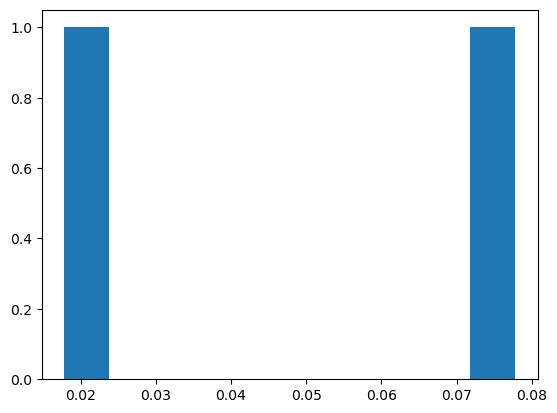

In [18]:
dia_object, dia_obj_info_frame = plot_catalog_histogram("dia_object")

## Dia Object Collection

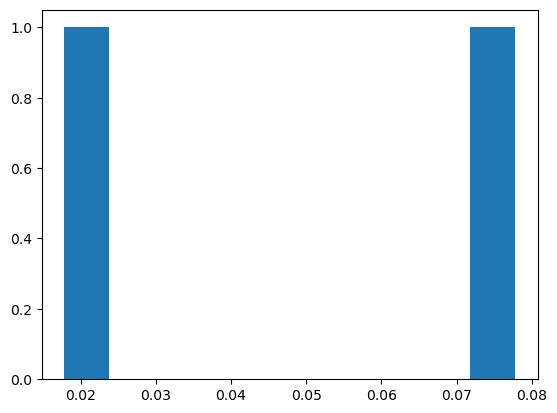

In [18]:
dia_object_col, dia_object_col_info_frame = plot_catalog_histogram("dia_object_collection/dia_object_lc")

## Dia Object Forced Source

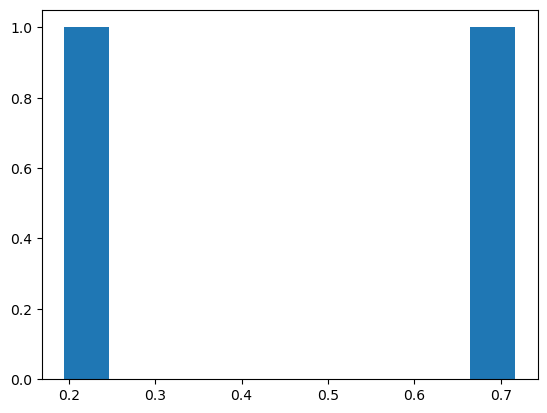

In [19]:
dia_object_forced_src, dia_object_forced_src_info_frame = plot_catalog_histogram("dia_object_forced_source")

## Dia Source

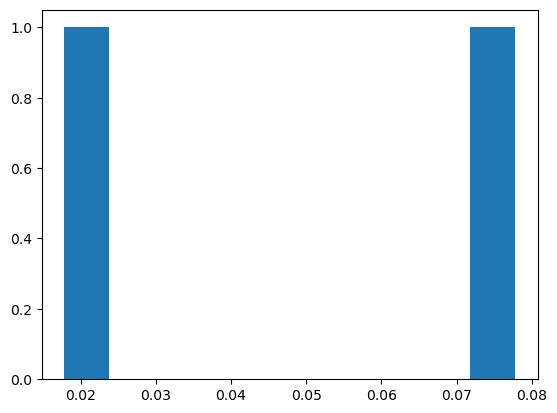

In [18]:
dia_source, dia_src_info_frame = plot_catalog_histogram("dia_source")